# Feature Engineering (80k) - Impact sur les modeles

Ce notebook reprend le pipeline du modele initial, mais limite volontairement le dataset a 80 000 exemples labels pour etudier l'effet des features sur la performance.

Objectifs :
- Mesurer la contribution de chaque groupe de features sur Random Forest et Linear SVM.
- Justifier les choix de features avec des mesures quantitatives (deltas d'ablation).
- Construire une base solide pour un rapport et une presentation.

Pourquoi ce sujet est critique :
- La performance depend autant de la representation que de l'algorithme.
- Des features inutiles peuvent ajouter du bruit et degrader la generalisation.
- Une etude d'ablation permet d'argumenter des choix techniques de maniere defendable.

## Setup

In [25]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score, f1_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')

DATA_PATH = "../data/raw/multinli_1.0/multinli_1.0_train.jsonl"
MAX_SAMPLES = 80000

print(f"Dataset path: {DATA_PATH}")
print(f"Max samples: {MAX_SAMPLES}")

Dataset path: ../data/raw/multinli_1.0/multinli_1.0_train.jsonl
Max samples: 80000


## 1. Load Dataset and Basic Diagnostics

Lecture du fichier JSONL, filtrage des labels invalides, limitation a 80k exemples, puis diagnostic de distribution des labels.

In [26]:
data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item["gold_label"] == "-":
            continue
        data.append(item)
        if len(data) >= MAX_SAMPLES:
            break

df = pd.DataFrame(data)[["sentence1", "sentence2", "gold_label"]]

print(f"Dataset: {len(df)} samples")
print("\nLabel distribution:")
print(df["gold_label"].value_counts())

Dataset: 80000 samples

Label distribution:
gold_label
contradiction    28394
entailment       27122
neutral          24484
Name: count, dtype: int64


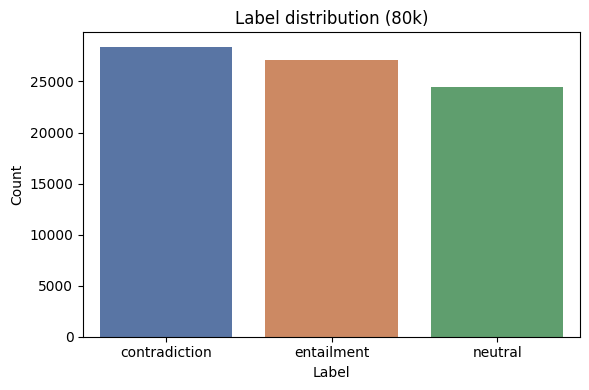

In [27]:
label_counts = df["gold_label"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="deep")
plt.title("Label distribution (80k)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Label Mapping and Text Extraction

Mapping des labels, extraction des paires de phrases et exemples rapides pour controle.

In [28]:
label_mapping = {"entailment": 0, "neutral": 1, "contradiction": 2}

sentence1_texts = df["sentence1"].values
sentence2_texts = df["sentence2"].values
labels = df["gold_label"].map(label_mapping).values

print(f"Sentence1 shape: {sentence1_texts.shape}")
print(f"Sentence2 shape: {sentence2_texts.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nExample sentence1:\n{sentence1_texts[0][:120]}...")
print(f"Example sentence2:\n{sentence2_texts[0][:120]}...")

Sentence1 shape: (80000,)
Sentence2 shape: (80000,)
Labels shape: (80000,)

Example sentence1:
Conceptually cream skimming has two basic dimensions - product and geography....
Example sentence2:
Product and geography are what make cream skimming work. ...


## 3. TF-IDF Vectorization for Sentence Pairs

Vectorisation TF-IDF au niveau des mots sur la phrase 1, puis transformation de la phrase 2 avec le meme vocabulaire.

In [29]:
word_vectorizer = TfidfVectorizer(
    max_features=20000,
    max_df=0.9,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm='l2',
    analyzer='word'
)

X1_word = word_vectorizer.fit_transform(sentence1_texts)
X2_word = word_vectorizer.transform(sentence2_texts)
X_tfidf = hstack([X1_word, X2_word]).tocsr()

print(f"X1_word shape: {X1_word.shape}")
print(f"X2_word shape: {X2_word.shape}")
print(f"X_tfidf shape: {X_tfidf.shape}")

X1_word shape: (80000, 20000)
X2_word shape: (80000, 20000)
X_tfidf shape: (80000, 40000)


## 4. Interaction and Handcrafted Feature Engineering

Construction de features d'interaction (cosine, diff, mult) et features simples (Jaccard, longueurs, negations) puis normalisation.

In [30]:
print("Computing interaction features...")

cosine_sim_word = np.array([
    cosine_similarity(X1_word[i], X2_word[i])[0][0]
    for i in range(X1_word.shape[0])
]).reshape(-1, 1)

X_diff = X1_word - X2_word
X_mult = X1_word.multiply(X2_word)


def enhanced_features(s1_array, s2_array):
    jaccard_list = []
    len1_list = []
    len2_list = []
    len_ratio_list = []
    len_diff_list = []
    neg1_list = []
    neg2_list = []
    neg_diff_list = []

    negations = {'not', 'no', 'never', 'neither', 'none', 'nobody', "n't", 'nothing', 'nowhere'}

    for s1, s2 in zip(s1_array, s2_array):
        words1 = s1.lower().split()
        words2 = s2.lower().split()
        set1, set2 = set(words1), set(words2)

        jaccard_list.append(len(set1 & set2) / len(set1 | set2) if len(set1 | set2) > 0 else 0)

        len1, len2 = len(words1), len(words2)
        len1_list.append(len1)
        len2_list.append(len2)
        len_ratio_list.append(min(len1, len2) / max(len1, len2) if max(len1, len2) > 0 else 0)
        len_diff_list.append(abs(len1 - len2))

        neg1 = sum(1 for w in words1 if w in negations)
        neg2 = sum(1 for w in words2 if w in negations)
        neg1_list.append(neg1)
        neg2_list.append(neg2)
        neg_diff_list.append(abs(neg1 - neg2))

    return {
        'jaccard': np.array(jaccard_list).reshape(-1, 1),
        'len1': np.array(len1_list).reshape(-1, 1),
        'len2': np.array(len2_list).reshape(-1, 1),
        'len_ratio': np.array(len_ratio_list).reshape(-1, 1),
        'len_diff': np.array(len_diff_list).reshape(-1, 1),
        'neg1': np.array(neg1_list).reshape(-1, 1),
        'neg2': np.array(neg2_list).reshape(-1, 1),
        'neg_diff': np.array(neg_diff_list).reshape(-1, 1)
    }

print("Extracting enhanced features...")
enhanced_feats = enhanced_features(sentence1_texts, sentence2_texts)

scaler = StandardScaler()
enhanced_feats_scaled = {k: scaler.fit_transform(v) for k, v in enhanced_feats.items()}

print(f"Handcrafted feature blocks: {list(enhanced_feats_scaled.keys())}")

Computing interaction features...
Extracting enhanced features...
Handcrafted feature blocks: ['jaccard', 'len1', 'len2', 'len_ratio', 'len_diff', 'neg1', 'neg2', 'neg_diff']


## 5. Feature Stacking and Shape Audit

Empilement des blocs TF-IDF, interactions et features handcrafted dans une matrice sparse finale.

In [31]:
X_full = hstack([
    X1_word,
    X2_word,
    X_diff,
    X_mult,
    cosine_sim_word,
    enhanced_feats_scaled['jaccard'],
    enhanced_feats_scaled['len1'],
    enhanced_feats_scaled['len2'],
    enhanced_feats_scaled['len_ratio'],
    enhanced_feats_scaled['len_diff'],
    enhanced_feats_scaled['neg1'],
    enhanced_feats_scaled['neg2'],
    enhanced_feats_scaled['neg_diff']
]).tocsr()

print(f"Final feature matrix shape: {X_full.shape}")
print(f"TF-IDF dims (both sentences): {X1_word.shape[1] * 2}")
print(f"Interactions dims (diff + mult + cosine): {X1_word.shape[1] * 2 + 1}")
print(f"Handcrafted dims: {len(enhanced_feats_scaled)}")

Final feature matrix shape: (80000, 80009)
TF-IDF dims (both sentences): 40000
Interactions dims (diff + mult + cosine): 40001
Handcrafted dims: 8


## 6. Train/Test Split and Sparse Scaling

Separation train/test et normalisation MaxAbs pour la branche SVM (compatible sparse).

In [32]:
indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=labels
)

X_train = X_full[train_idx]
X_test = X_full[test_idx]
X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf = X_tfidf[test_idx]
y_train = labels[train_idx]
y_test = labels[test_idx]

svm_scaler = MaxAbsScaler()
X_train_svm = svm_scaler.fit_transform(X_train)
X_test_svm = svm_scaler.transform(X_test)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features (full): {X_train.shape[1]}")
print(f"Features (tfidf): {X_train_tfidf.shape[1]}")
print(f"SVM-scaled train matrix shape: {X_train_svm.shape}")

Train samples: 64000
Test samples: 16000
Features (full): 80009
Features (tfidf): 40000
SVM-scaled train matrix shape: (64000, 80009)


## 7. Random Forest Training and Evaluation

Entrainement RF sur toutes les features et evaluation (accuracy + kappa).

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=60,
    min_samples_split=20,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    random_state=43,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
kappa_rf = cohen_kappa_score(y_test, y_pred_rf)

print(f"RF Accuracy: {accuracy_rf:.4f}")
print(f"RF Cohen's Kappa: {kappa_rf:.4f}")

RF Accuracy: 0.5687
RF Cohen's Kappa: 0.3549


## 8. Linear SVM Training with Optional SVD

Optionnellement reduire la dimension avec SVD, puis entrainer un LinearSVC sur les features scalees.

In [34]:
use_svd = False

if use_svd:
    n_components = 500
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_train_use = svd.fit_transform(X_train_svm)
    X_test_use = svd.transform(X_test_svm)
    explained_variance = svd.explained_variance_ratio_.sum()
    print(f"SVD explained variance: {explained_variance:.4f}")
else:
    X_train_use = X_train_svm
    X_test_use = X_test_svm

svm_model = LinearSVC(
    C=1.5,
    max_iter=5000,
    random_state=42,
    dual=False,
    class_weight='balanced',
    loss='squared_hinge'
)

svm_model.fit(X_train_use, y_train)

y_pred_svm = svm_model.predict(X_test_use)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
kappa_svm = cohen_kappa_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Cohen's Kappa: {kappa_svm:.4f}")

SVM Accuracy: 0.4529
SVM Cohen's Kappa: 0.1775


## 9. Metrics, Reports, and Confusion Matrix

Rapports de classification et matrices de confusion pour RF et SVM, avec precision par classe.

RF Classification Report
                      precision    recall  f1-score   support

   Entailment (VRAI)       0.55      0.67      0.60      5424
Neutral (A_VERIFIER)       0.52      0.59      0.55      4897
Contradiction (FAUX)       0.68      0.46      0.55      5679

            accuracy                           0.57     16000
           macro avg       0.58      0.57      0.57     16000
        weighted avg       0.58      0.57      0.57     16000

RF Confusion Matrix:
[[3617 1232  575]
 [1365 2873  659]
 [1613 1457 2609]]
RF Entailment: 0.6669
RF Neutral: 0.5867
RF Contradiction: 0.4594


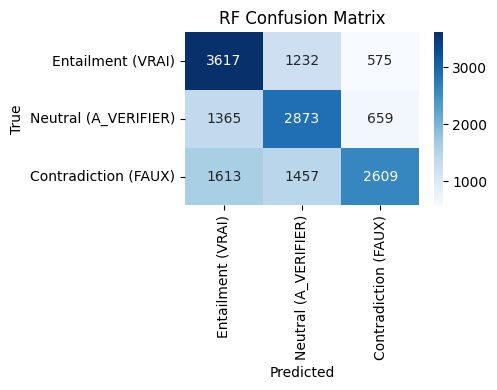

SVM Classification Report
                      precision    recall  f1-score   support

   Entailment (VRAI)       0.46      0.45      0.46      5424
Neutral (A_VERIFIER)       0.41      0.40      0.41      4897
Contradiction (FAUX)       0.48      0.50      0.49      5679

            accuracy                           0.45     16000
           macro avg       0.45      0.45      0.45     16000
        weighted avg       0.45      0.45      0.45     16000

SVM Confusion Matrix:
[[2445 1426 1553]
 [1436 1983 1478]
 [1435 1425 2819]]
SVM Entailment: 0.4508
SVM Neutral: 0.4049
SVM Contradiction: 0.4964


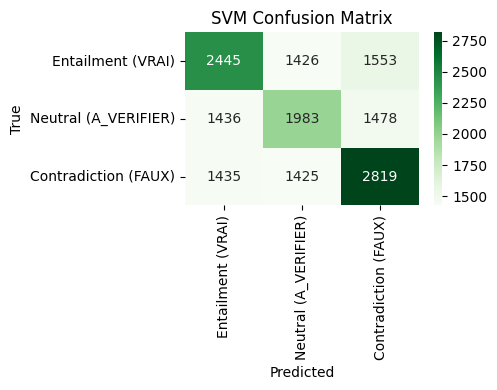

In [35]:
target_names = ["Entailment (VRAI)", "Neutral (A_VERIFIER)", "Contradiction (FAUX)"]

print("=" * 60)
print("RF Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=target_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("RF Confusion Matrix:")
print(cm_rf)
for i, label in enumerate(["Entailment", "Neutral", "Contradiction"]):
    class_acc = cm_rf[i, i] / cm_rf[i].sum()
    print(f"RF {label}: {class_acc:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("=" * 60)
print("SVM Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_svm, target_names=target_names))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("SVM Confusion Matrix:")
print(cm_svm)
for i, label in enumerate(["Entailment", "Neutral", "Contradiction"]):
    class_acc = cm_svm[i, i] / cm_svm[i].sum()
    print(f"SVM {label}: {class_acc:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens", xticklabels=target_names, yticklabels=target_names)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 9. Sequential Feature Ablation Benchmark

Ablation sequentielle retrograde : on retire une feature a la fois et on observe le delta de performance.

Pourquoi l'etudier plus intelligemment :
- Cela permet d'identifier les features qui apportent un vrai signal.
- Les deltas montrent quelles features degradent la generalisation.
- On obtient un argumentaire mesurable pour les choix d'architecture.

In [45]:
feature_groups_seq = [
    ("s1_tfidf", X1_word),
    ("s2_tfidf", X2_word),
    ("word_diff", X_diff),
    ("word_mult", X_mult),
    ("cosine_word", csr_matrix(cosine_sim_word)),
    ("jaccard", csr_matrix(enhanced_feats_scaled['jaccard'])),
    ("len1", csr_matrix(enhanced_feats_scaled['len1'])),
    ("len2", csr_matrix(enhanced_feats_scaled['len2'])),
    ("len_ratio", csr_matrix(enhanced_feats_scaled['len_ratio'])),
    ("len_diff", csr_matrix(enhanced_feats_scaled['len_diff'])),
    ("neg1", csr_matrix(enhanced_feats_scaled['neg1'])),
    ("neg2", csr_matrix(enhanced_feats_scaled['neg2'])),
    ("neg_diff", csr_matrix(enhanced_feats_scaled['neg_diff'])),
]

stack = lambda groups: hstack([m for _, m in groups])

X_all_seq = stack(feature_groups_seq)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_seq, labels, test_size=0.2, random_state=42, stratify=labels
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=60,
    min_samples_split=20,
    min_samples_leaf=6,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    random_state=43,
    n_jobs=-1,
    verbose=0
)
rf.fit(X_tr, y_tr)
base_rf_acc = accuracy_score(y_te, rf.predict(X_te))

scaler_ab = MaxAbsScaler()
X_tr_svm = scaler_ab.fit_transform(X_tr)
X_te_svm = scaler_ab.transform(X_te)
svm = LinearSVC(
    C=3,
    max_iter=5000,
    random_state=42,
    dual=False,
    class_weight='balanced',
    loss='squared_hinge'
)
svm.fit(X_tr_svm, y_tr)
base_svm_acc = accuracy_score(y_te, svm.predict(X_te_svm))

print(f"Baseline RF: {base_rf_acc:.4f} | SVM: {base_svm_acc:.4f}")

current_groups = feature_groups_seq.copy()
prev_rf_acc, prev_svm_acc = base_rf_acc, base_svm_acc
seq_results = []

for remove_idx in range(len(current_groups) - 1, 1, -1):
    removed_name, _ = current_groups[remove_idx]
    current_groups = current_groups[:remove_idx]
    X_cur = stack(current_groups)
    X_tr_cur, X_te_cur, y_tr_cur, y_te_cur = train_test_split(
        X_cur, labels, test_size=0.2, random_state=42, stratify=labels
    )

    rf_cur = RandomForestClassifier(
        n_estimators=400,
        max_depth=60,
        min_samples_split=20,
        min_samples_leaf=6,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        random_state=43,
        n_jobs=-1,
        verbose=0
    )
    rf_cur.fit(X_tr_cur, y_tr_cur)
    cur_rf_acc = accuracy_score(y_te_cur, rf_cur.predict(X_te_cur))

    scaler_cur = MaxAbsScaler()
    X_tr_svm_cur = scaler_cur.fit_transform(X_tr_cur)
    X_te_svm_cur = scaler_cur.transform(X_te_cur)
    svm_cur = LinearSVC(
        C=3,
        max_iter=5000,
        random_state=42,
        dual=False,
        class_weight='balanced',
        loss='squared_hinge'
    )
    svm_cur.fit(X_tr_svm_cur, y_tr_cur)
    cur_svm_acc = accuracy_score(y_te_cur, svm_cur.predict(X_te_svm_cur))

    seq_results.append({
        'removed_feature': removed_name,
        'rf_acc': cur_rf_acc,
        'svm_acc': cur_svm_acc,
        'rf_delta': prev_rf_acc - cur_rf_acc,
        'svm_delta': prev_svm_acc - cur_svm_acc
    })
    print(f"Removed {removed_name:>12} -> RF Δ {prev_rf_acc - cur_rf_acc:.4f} | SVM Δ {prev_svm_acc - cur_svm_acc:.4f}")
    prev_rf_acc, prev_svm_acc = cur_rf_acc, cur_svm_acc

seq_ablation_results = pd.DataFrame(seq_results)
print("\nSequential removal summary (larger Δ = more contribution):")
print(seq_ablation_results[['removed_feature', 'svm_delta', 'rf_delta']].to_string(index=False))

Baseline RF: 0.5687 | SVM: 0.4471
Removed     neg_diff -> RF Δ 0.0042 | SVM Δ 0.0030
Removed         neg2 -> RF Δ -0.0024 | SVM Δ 0.0015
Removed         neg1 -> RF Δ 0.0012 | SVM Δ 0.0003
Removed     len_diff -> RF Δ 0.0011 | SVM Δ 0.0004
Removed    len_ratio -> RF Δ -0.0001 | SVM Δ 0.0004
Removed         len2 -> RF Δ 0.0026 | SVM Δ 0.0026
Removed         len1 -> RF Δ 0.0011 | SVM Δ -0.0008
Removed      jaccard -> RF Δ -0.0031 | SVM Δ 0.0016
Removed  cosine_word -> RF Δ 0.0171 | SVM Δ 0.0040
Removed    word_mult -> RF Δ 0.0043 | SVM Δ 0.0277
Removed    word_diff -> RF Δ 0.0303 | SVM Δ -0.0001

Sequential removal summary (larger Δ = more contribution):
removed_feature  svm_delta  rf_delta
       neg_diff   0.003000  0.004188
           neg2   0.001500 -0.002437
           neg1   0.000250  0.001188
       len_diff   0.000437  0.001062
      len_ratio   0.000438 -0.000125
           len2   0.002562  0.002625
           len1  -0.000812  0.001125
        jaccard   0.001625 -0.003125
    cos

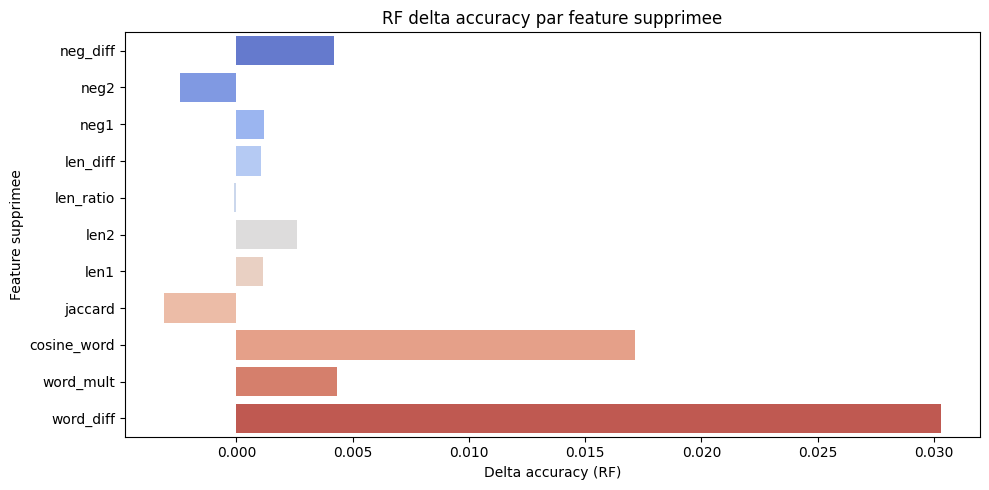

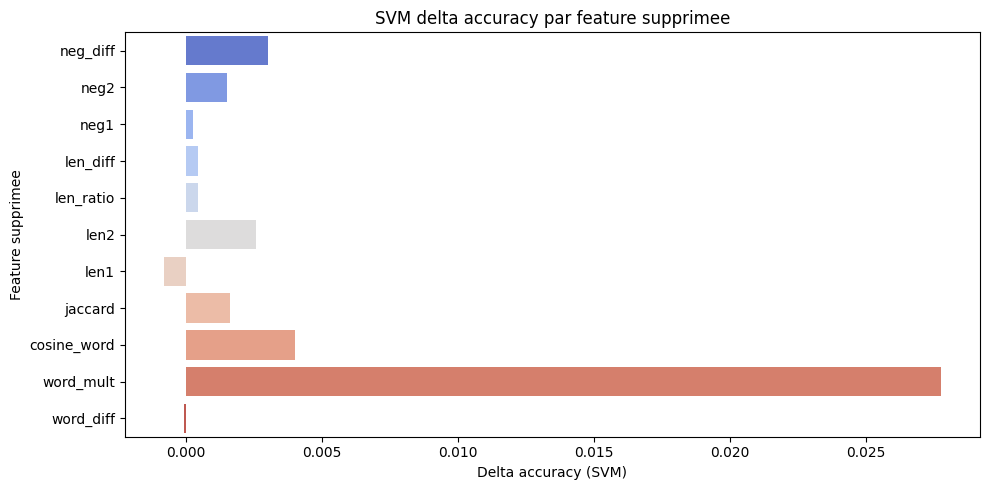

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(data=seq_ablation_results, x="rf_delta", y="removed_feature", palette="coolwarm")
plt.title("RF delta accuracy par feature supprimee")
plt.xlabel("Delta accuracy (RF)")
plt.ylabel("Feature supprimee")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=seq_ablation_results, x="svm_delta", y="removed_feature", palette="coolwarm")
plt.title("SVM delta accuracy par feature supprimee")
plt.xlabel("Delta accuracy (SVM)")
plt.ylabel("Feature supprimee")
plt.tight_layout()
plt.show()

## 11. Export Ablation Results to CSV

Export des resultats pour la visualisation et le rapport final.

In [47]:
out_dir = os.path.join(os.path.dirname(__file__) if '__file__' in globals() else '.', 'results')
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, 'ablation_sequential_backward_80k.csv')
seq_ablation_results.to_csv(out_path, index=False)

print(f"Saved ablation results to: {out_path}")

Saved ablation results to: .\results\ablation_sequential_backward_80k.csv
